Test and plot results from the warpcoeff_color process:
- For some sample class
- Load the fitted distribution
- Load a bunch of templates with random colors drawn
- Compare peak colors of templates with distribution


In [1]:
import os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from scipy.optimize import curve_fit
from scipy.stats import exponnorm
from pathlib import Path
from datetime import datetime
import sncosmo
import extinction
from scipy.optimize import brentq
import pickle

In [2]:
sys.path.append('/Users/jnordin/github/ampelFeb25')

In [3]:
from warpTemplate import WarpfitTemplateLoader

In [4]:
template_class_id = 9

In [5]:
# NOw you have to decide which warp class to fit against:
warpclasses = [
    'SN Ib', 'SN Ia-91bg', 'SN II', 'SN Ia-91T',
    'SN Ib/c', 'SN Ia-pec', 'SN IIP', 'SN Iax', 'SN Ic',
    'SLSN-II']

In [6]:
print('Fitting to templates of class', warpclasses[template_class_id])

Fitting to templates of class SLSN-II


In [7]:
# Help methods to get mean color for model
def get_latest_model_result(model_name, infile="warptemplate_color_fits.csv"):
    file = Path(infile)

    if not file.exists():
        raise FileNotFoundError(f"{infile} does not exist")

    # Load data
    df = pd.read_csv(file)

    if df.empty:
        return None

    # Ensure timestamp is datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Filter by model
    df_model = df[df["model"] == model_name]

    if df_model.empty:
        return None

    # Get latest entry
    latest_row = df_model.sort_values("timestamp", ascending=False).iloc[0]

    return latest_row.to_dict()

In [8]:
model_colors = get_latest_model_result(warpclasses[template_class_id])

In [9]:
model_colors

{'model': 'SLSN-II',
 'K': 0.0008168399116896,
 'loc': -0.0925309580442964,
 'scale': 0.4913880249067912,
 'color1': 'ztfr',
 'color2': 'ztfi',
 'n': 45,
 'timestamp': Timestamp('2026-05-28 13:19:52.102290')}

In [10]:
# Now we know which peak color the warped templates should be shifted 

In [11]:
# Parameters for fit template retrieval
# How to define templates?
# - How many templates per sn basis? 
#      * if 'all' it will return one copy of each template, 
#.     * if int it will return that many, drawn according to the template probability, 
#      * if -int it will return that many copies drawn from a uniform probabilitiy
#      Note: draws made with replacement, so multiple copies can be returned if int is larger than the available number of templates (often 3)
template_selection = 60    # Use the same number per SN to keep balance 
# - How many sn basis?
#.     * if 'all', take one of each
#.     * if an int, draw these randomly (with replacement)
#.     Note: how many templates are returned is decided by the above parameter.
snbasis_selection = 'all'

warpdir = '/Users/jnordin/data/models/sncosmo/warpmod'

In [12]:
warploader = WarpfitTemplateLoader(warpdir)

In [13]:
templates_raw = warploader.get_templates(
    fitclass=warpclasses[template_class_id],
    exclude_input = [],    # Here we do not wish to exclude anything 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    random_seed=42, 
    color_mode=None,
)

2026-05-28 18:34:16,140 [INFO] Using random seed: 42
2026-05-28 18:34:16,141 [INFO] Loading warpcoeffs from /Users/jnordin/data/models/sncosmo/warpmod/warpcoeffs_SLSN-II_distinfo.pkl
2026-05-28 18:34:16,145 [INFO] 16 SN bases available after filtering
2026-05-28 18:34:17,955 [INFO] Returning 960 templates


In [14]:
templates_harm = warploader.get_templates(
    fitclass=warpclasses[template_class_id],
    exclude_input = [],    # Here we do not wish to exclude anything 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    random_seed=42, 
    color_mode='harmonize',
)

2026-05-28 18:34:17,958 [INFO] Using random seed: 42
2026-05-28 18:34:17,958 [INFO] 16 SN bases available after filtering
2026-05-28 18:34:18,543 [INFO] Returning 960 templates


In [15]:
templates_draw = warploader.get_templates(
    fitclass=warpclasses[template_class_id],
    exclude_input = [],    # Here we do not wish to exclude anything 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    random_seed=42, 
    color_mode='draw',
)

2026-05-28 18:34:18,546 [INFO] Using random seed: 42
2026-05-28 18:34:18,546 [INFO] 16 SN bases available after filtering
2026-05-28 18:34:19,119 [INFO] Returning 960 templates


In [16]:
# Loop through templates and get peak colors
rawcols = []
for k, t in enumerate(templates_raw):
    mod = t['model']
    try:
        col = mod.bandmag('ztfg', "ab", 0) - mod.bandmag('ztfr', "ab", 0)
    except ValueError:
        print('no coverage')
        continue
    if col>-10:
        rawcols.append( col )
    else:
        print('nan color')

no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage


In [17]:
# Loop through templates and get peak colors
harmcols = []
for k, t in enumerate(templates_harm):
    mod = t['model']
    try:
        col = mod.bandmag('ztfg', "ab", 0) - mod.bandmag('ztfr', "ab", 0)
    except ValueError:
        print('no coverage')
        continue
    if col>-10:
        harmcols.append( col )
    else:
        print('nan color')

no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage


In [18]:
# Loop through templates and get peak colors
drawcols = []
for k, t in enumerate(templates_draw):
    mod = t['model']
    try:
        col = mod.bandmag('ztfg', "ab", 0) - mod.bandmag('ztfr', "ab", 0)
    except ValueError:
        print('no coverage')
        continue
    if col>-10:
        drawcols.append( col )
    else:
        print('nan color')

no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage
no coverage


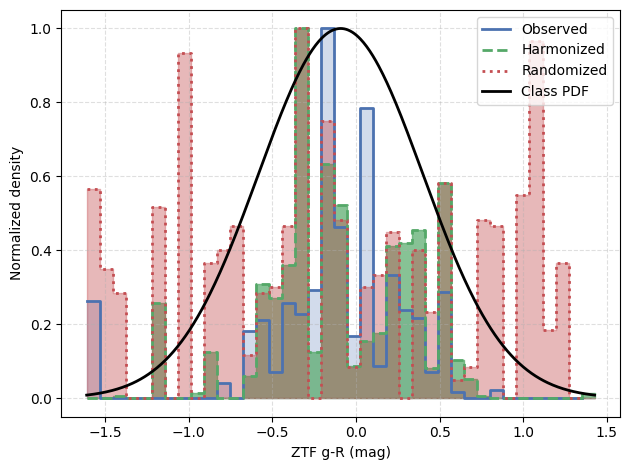

In [19]:
# Create x range
x = np.linspace(exponnorm.ppf(0.001, model_colors['K'], loc=model_colors['loc'], scale=model_colors['scale']),
                exponnorm.ppf(0.999, model_colors['K'], loc=model_colors['loc'], scale=model_colors['scale']),
                500)

# Combine data to define common bins
bins = np.linspace(exponnorm.ppf(0.001, model_colors['K'], loc=model_colors['loc'], scale=model_colors['scale']),
                exponnorm.ppf(0.999, model_colors['K'], loc=model_colors['loc'], scale=model_colors['scale']),
                40)

# PDF
pdf = exponnorm.pdf(x, model_colors['K'], loc=model_colors['loc'], scale=model_colors['scale'])
pdf /= pdf.max()

def step_hist_peaknorm(data, bins):
    counts, edges = np.histogram(data, bins=bins, density=True)
    counts = counts / counts.max()  # normalize to peak = 1
    return edges, counts
def plot_filled_step(edges, counts, color, label, alpha=0.25,linestyle='solid'):
    x = np.repeat(edges, 2)[1:-1]
    y = np.repeat(counts, 2)
    
    plt.fill_between(x, y, step='pre', alpha=alpha, color=color)
    plt.step(edges[:-1], counts, where='post', color=color, lw=2, label=label, linestyle=linestyle)


# Compute normalized histograms
edges_r, counts_r = step_hist_peaknorm(rawcols, bins)
edges_h, counts_h = step_hist_peaknorm(harmcols, bins)
edges_d, counts_d = step_hist_peaknorm(drawcols, bins)

# Draw step plots (note: edges[:-1] matches counts)
#plt.step(edges_r[:-1], counts_r, where='post', color='#4C72B0', lw=2, label='raw')
#plt.step(edges_h[:-1], counts_h, where='post', color='#55A868', lw=2, label='harm')
#plt.step(edges_d[:-1], counts_d, where='post', color='#C44E52', lw=2, label='draw')


plot_filled_step(edges_r, counts_r, '#4C72B0', 'Observed',linestyle='solid')
plot_filled_step(edges_h, counts_h, '#55A868', 'Harmonized',linestyle='dashed',alpha=0.7)
plot_filled_step(edges_d, counts_d, '#C44E52', 'Randomized',linestyle='dotted',alpha=0.4)


plt.plot(x, pdf, color='black', lw=2, label='Class PDF')
plt.grid(linestyle="--", alpha=0.4)
plt.legend()
plt.xlabel("ZTF g-R (mag)")
plt.ylabel("Normalized density")
#plt.title("Fitted Exponentially Modified Normal Distribution")
plt.tight_layout()
if template_class_id == 4:
    plt.savefig('color_distcomp_SN Ibc.pdf'.format(warpclasses[template_class_id]),dpi=300)
else:
    plt.savefig('color_distcomp_{}.pdf'.format(warpclasses[template_class_id]),dpi=300)

plt.show()